# 🧠 Modelo 7: Transfer Learning con ResNet50 + Data Augmentation

En este notebook utilizamos la arquitectura **ResNet50** preentrenada en ImageNet, aplicando **Data Augmentation** para mejorar la generalización del modelo y reducir el sobreajuste. Implementamos técnicas de aumento de datos como rotaciones, flips, zoom y ajustes de brillo.

---

In [1]:
import os
import sys

# ⚠️ IMPORTANTE: Estas líneas DEBEN ir ANTES de importar TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suprime todos los mensajes (INFO, WARNING, ERROR)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Desactiva mensajes de oneDNN
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Suprimir warnings de TensorFlow adicionales
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_resnet50_unfrozen as resnet_model

print("✅ Librerías e importaciones listas")

✅ Librerías e importaciones listas


In [2]:
# Configurar GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {(gpu)}")
    except RuntimeError as e:
        print(e)
else:
    print(" No se detectó GPU. Se usará la CPU.")

GPU detectada(s): PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 1. Carga de Datos (RGB para ResNet50)

**IMPORTANTE**: ResNet50 está diseñado para imágenes en color (3 canales). Por ello, configuramos `color_mode='rgb'` en el dataloader.

In [8]:
# Descargar/Localizar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

# Configuración del DataLoader
IMG_SIZE = (224, 224)
BATCH_SIZE = 256
SUBSET = 1 

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb', # <--- OBLIGATORIO para ResNet50
    train_subset_fraction=SUBSET, 
    optimize=False
)

⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (224, 224)
   • Batch size: 256
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      299 batches
Validation: 86 batches
Test:       43 batches



## 1.1. Aplicación de Data Augmentation

Aplicamos técnicas de **Data Augmentation** al dataset de entrenamiento para aumentar la variabilidad de los datos y mejorar la capacidad de generalización del modelo. Las transformaciones incluyen:

- **Rotación aleatoria**: hasta 15 grados
- **Flip horizontal**: aleatorio
- **Zoom**: hasta 10%
- **Ajustes de brillo y contraste**: aleatorios

In [9]:
from tensorflow.keras import layers

# Definir las capas de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),  # Rotación de hasta 15 grados
    layers.RandomZoom(0.1),  # Zoom de hasta 10%
    layers.RandomContrast(0.1),  # Ajuste de contraste
    layers.RandomBrightness(0.1),  # Ajuste de brillo
], name="data_augmentation")

# Aplicar data augmentation solo al dataset de entrenamiento
def augment_data(image, label):
    return data_augmentation(image, training=True), label

# Aplicar augmentation al dataset de entrenamiento
train_ds_augmented = train_ds.map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Optimizar el pipeline
train_ds_augmented = train_ds_augmented.prefetch(tf.data.AUTOTUNE)

### Visualización de Data Augmentation

Veamos cómo se ven las imágenes después de aplicar data augmentation:

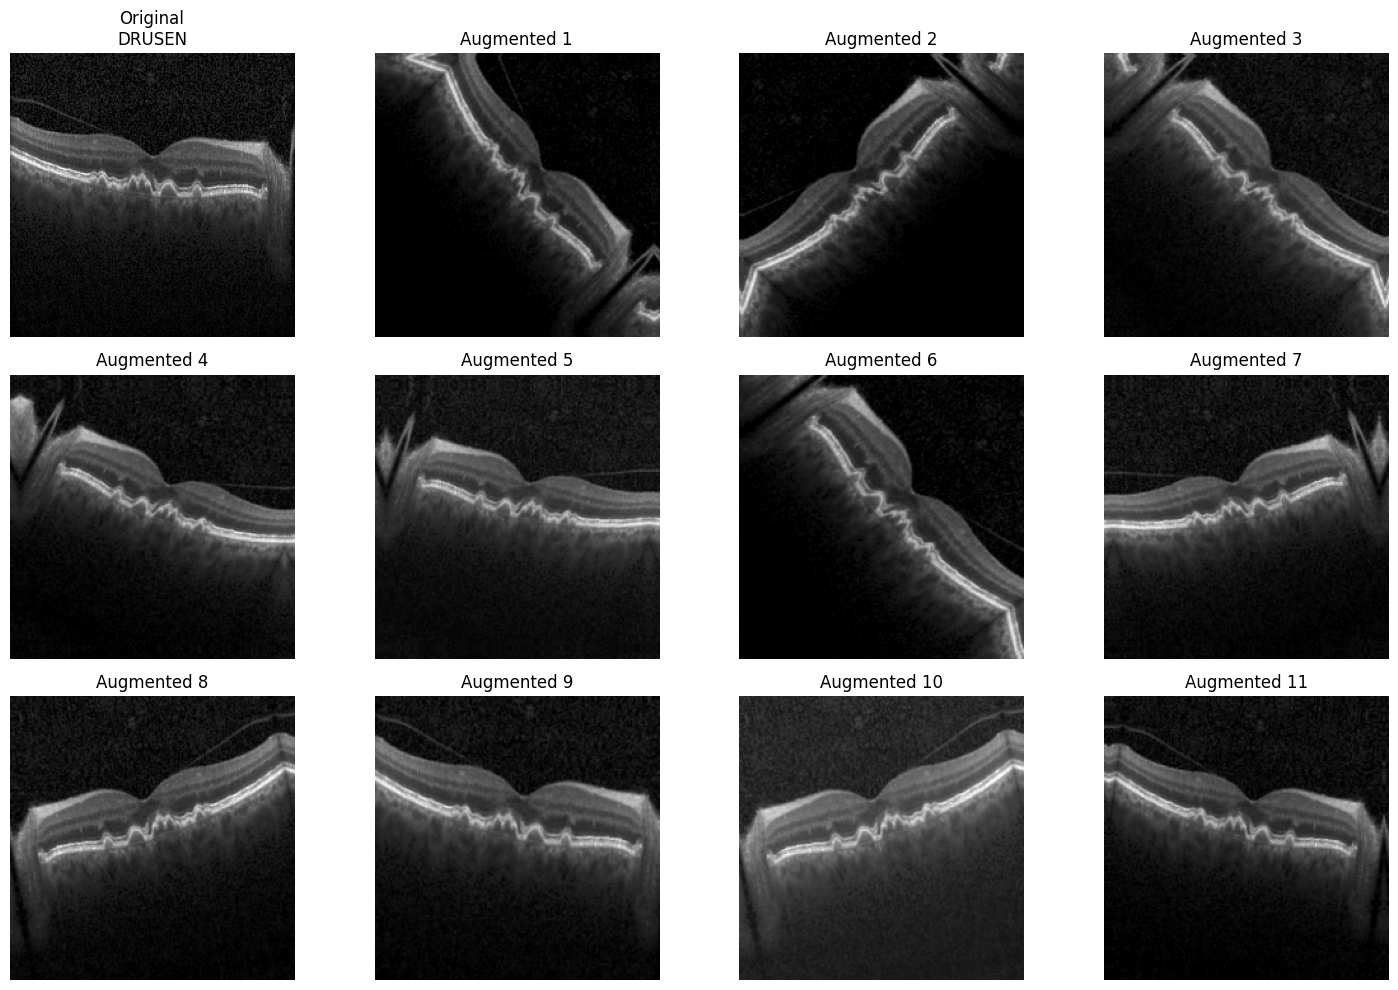

In [10]:

# Visualizar ejemplos de data augmentation
plt.figure(figsize=(15, 10))

# Tomar una imagen del dataset
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    
    # Mostrar la imagen original
    plt.subplot(3, 4, 1)
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title(f"Original\n{class_names[int(sample_label)]}")
    plt.axis('off')
    
    # Mostrar 11 versiones aumentadas
    for i in range(11):
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        plt.subplot(3, 4, i + 2)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
plt.tight_layout()
plt.show()


## 2. Creación y Compilación del Modelo

ResNet50 tiene millones de parámetros. Descongelaremos sus capas progresivamente para aprovechar al máximo el data augmentation.

In [ ]:
from tensorflow.keras.metrics import AUC

# Hiperparámetros configurables
LEARNING_RATE = 1e-5
DROPOUT = 0.4

# 1. Crear el modelo con ResNet50
model = resnet_model.create_resnet_model(
    input_shape=(224, 224, 3), # (Ancho, Alto, Canales RGB)
    num_classes=4, 
    dropout_rate=DROPOUT
)

# 2. Compilar especificando métricas (incluyendo el AUC para mayor robustez)
metrics = [
    'accuracy'
]

model = resnet_model.compile_resnet_model(
    model, 
    learning_rate=LEARNING_RATE, 
    metrics=metrics
)

model.summary()

Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 24,060,676 (91.78 MB)

 Non-trainable params: 53,632 (209.50 KB)

## 3. Entrenamiento con Data Augmentation

Entrenamos el modelo utilizando el dataset aumentado. El data augmentation ayuda a reducir el sobreajuste y mejora la capacidad de generalización, especialmente útil cuando entrenamos con capas descongeladas.

In [ ]:
EPOCHS = 100

# Obtener callbacks avanzados
callbacks = resnet_model.get_resnet_callbacks(
    patience_stop=30, 
    patience_lr=2, 
    factor_lr=0.2
)

# Entrenar con el dataset aumentado
history = model.fit(
    train_ds_augmented,  # <--- Usar dataset con Data Augmentation
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1773305768.375101 1292454 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.7738 - loss: 0.5944
Epoch 1: val_loss improved from None to 0.27480, saving model to modelos/best_resnet50.weights.h5



Epoch 1: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 154s 352ms/step - accuracy: 0.8837 - loss: 0.3315 - val_accuracy: 0.9075 - val_loss: 0.2748 - learning_rate: 3.0000e-05
Epoch 2/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9478 - loss: 0.1623
Epoch 2: val_loss improved from 0.27480 to 0.19584, saving model to modelos/best_resnet50.weights.h5



Epoch 2: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 65s 213ms/step - accuracy: 0.9510 - loss: 0.1514 - val_accuracy: 0.9344 - val_loss: 0.1958 - learning_rate: 3.0000e-05
Epoch 3/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9576 - loss: 0.1252
Epoch 3: val_loss improved from 0.19584 to 0.11211, saving model to modelos/best_resnet50.weights.h5


...


Epoch 5: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 60s 196ms/step - accuracy: 0.9662 - loss: 0.0994 - val_accuracy: 0.9637 - val_loss: 0.1039 - learning_rate: 3.0000e-05
Epoch 6/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9687 - loss: 0.0932
Epoch 6: val_loss improved from 0.10391 to 0.10175, saving model to modelos/best_resnet50.weights.h5



Epoch 6: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 61s 200ms/step - accuracy: 0.9690 - loss: 0.0922 - val_accuracy: 0.9664 - val_loss: 0.1018 - learning_rate: 3.0000e-05
Epoch 7/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9695 - loss: 0.0887
Epoch 7: val_loss improved from 0.10175 to 0.08944, saving model to modelos/best_resnet50.weights.h5



Epoch 7: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 62s 200ms/step - accuracy: 0.9703 - loss: 0.0871 - val_accuracy: 0.9701 - val_loss: 0.0894 - learning_rate: 3.0000e-05
Epoch 8/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9720 - loss: 0.0826
Epoch 8: val_loss did not improve from 0.08944
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 190ms/step - accuracy: 0.9722 - loss: 0.0816 - val_accuracy: 0.9691 - val_loss: 0.0934 - learning_rate: 3.0000e-05
Epoch 9/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9737 - loss: 0.0750
Epoch 9: ReduceLROnPlateau reducing learning rate to 5.9999998484272515e-06.

Epoch 9: val_loss did not improve from 0.08944
299/299 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.9741 - loss: 0.0747 - val_accuracy: 0.9691 - val_loss: 0.0948 - learning_rate: 3.0000e-05
Epoch 10/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9769 - loss: 0.0676
Epoch 10: val_loss improved from 0.08944 to 0.08


Epoch 10: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 192ms/step - accuracy: 0.9779 - loss: 0.0644 - val_accuracy: 0.9726 - val_loss: 0.0815 - learning_rate: 6.0000e-06
Epoch 11/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9787 - loss: 0.0610
Epoch 11: val_loss did not improve from 0.08150
299/299 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.9789 - loss: 0.0605 - val_accuracy: 0.9719 - val_loss: 0.0832 - learning_rate: 6.0000e-06
Epoch 12/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9797 - loss: 0.0600
Epoch 12: val_loss improved from 0.08150 to 0.08095, saving model to modelos/best_resnet50.weights.h5



Epoch 12: finished saving model to modelos/best_resnet50.weights.h5
299/299 ━━━━━━━━━━━━━━━━━━━━ 61s 197ms/step - accuracy: 0.9799 - loss: 0.0589 - val_accuracy: 0.9732 - val_loss: 0.0809 - learning_rate: 6.0000e-06
Epoch 13/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9798 - loss: 0.0583
Epoch 13: val_loss did not improve from 0.08095
299/299 ━━━━━━━━━━━━━━━━━━━━ 58s 189ms/step - accuracy: 0.9805 - loss: 0.0574 - val_accuracy: 0.9732 - val_loss: 0.0815 - learning_rate: 6.0000e-06
Epoch 14/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9795 - loss: 0.0572
Epoch 14: ReduceLROnPlateau reducing learning rate to 1.1999999514955563e-06.

Epoch 14: val_loss did not improve from 0.08095
299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 186ms/step - accuracy: 0.9802 - loss: 0.0558 - val_accuracy: 0.9730 - val_loss: 0.0824 - learning_rate: 6.0000e-06
Epoch 15/100
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9809 - loss: 0.0532
Epoch 15: val_loss did not improve from 0.

## 4. Curvas de Aprendizaje y Evaluación

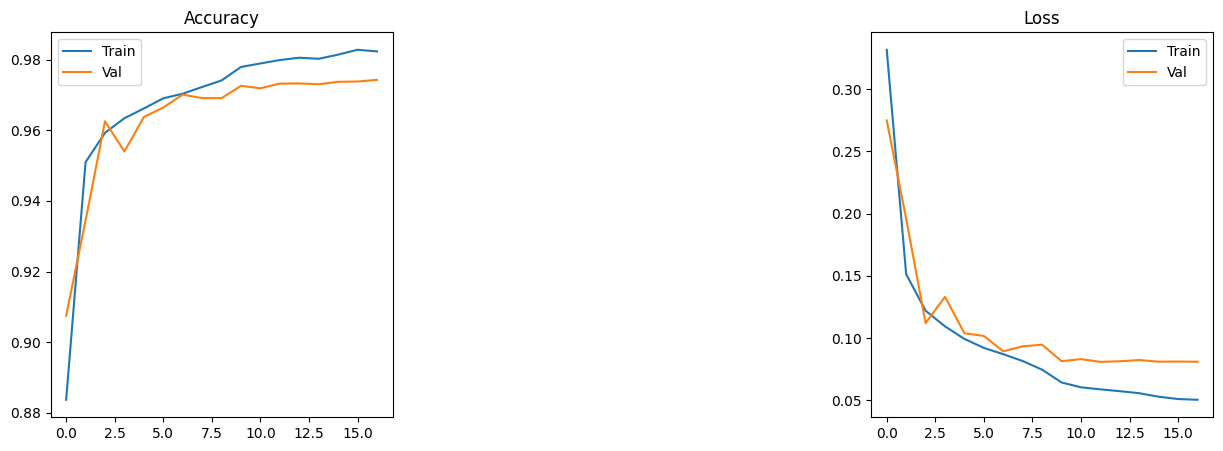

In [13]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()



plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()

Loss en test: 0.0933
Accuracy en test: 0.9700

AUC por clase (One-vs-Rest):
 - CNV: 0.9987
 - DME: 0.9978
 - DRUSEN: 0.9913
 - NORMAL: 0.9987

AUC Promedio (Macro): 0.9966

Reporte de clasificacion:
              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98      3746
         DME       0.96      0.95      0.95      1161
      DRUSEN       0.87      0.87      0.87       887
      NORMAL       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.95      0.95      0.95     10933
weighted avg       0.97      0.97      0.97     10933



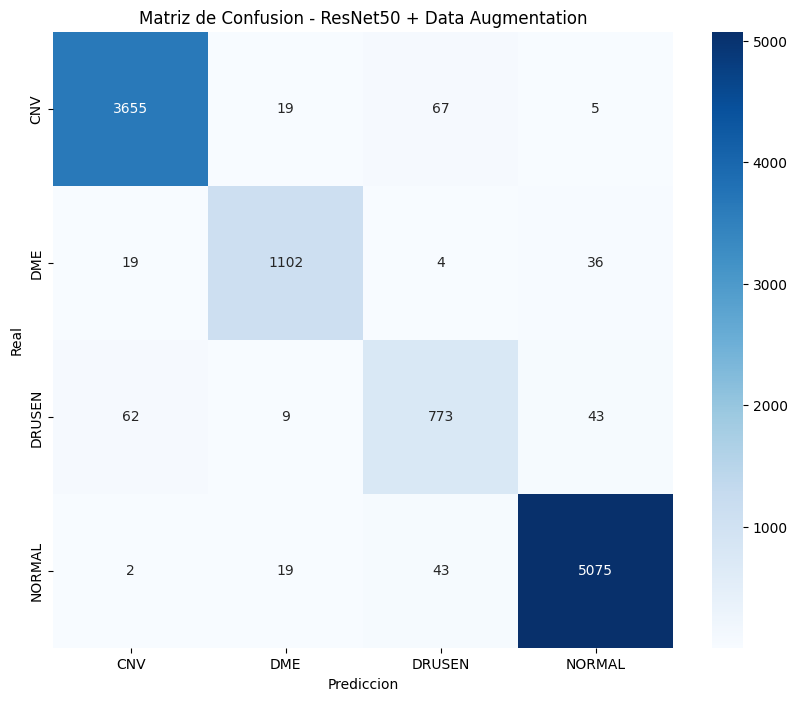

In [14]:
# --- Chunk: Evaluacion de Metricas Finales ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

results = model.evaluate(test_ds, verbose=0)
print(f"Loss en test: {results[0]:.4f}")
print(f"Accuracy en test: {results[1]:.4f}")

y_true = []
y_probs = []

# Obtencion de predicciones
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

# Calculo de AUC por clase
y_true_oh = to_categorical(y_true, num_classes=len(class_names))
print("\nAUC por clase (One-vs-Rest):")
auc_scores = []
for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_true_oh[:, i], y_probs[:, i])
    auc_scores.append(auc)
    print(f" - {class_name}: {auc:.4f}")

print(f"\nAUC Promedio (Macro): {np.mean(auc_scores):.4f}")

# Reporte de Clasificacion
print("\nReporte de clasificacion:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - ResNet50 + Data Augmentation')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()
